# Redes Neuronales con Pytorch

## Introduction

En este ejercicio se implementa una red neuronal para clasificación utilizando pytorch.

Antes de empezar la ejecución de las partes de codigo correspondientes, se requiere importar todas las librerias necesarias.

In [1]:
# utilizado para la manipulación de directorios y rutas
import os
# Cálculo científico y vectorial para python
import numpy as np
# Libreria para graficos
from matplotlib import pyplot as plt


import torch
import torchvision # torch package for vision related things
import torch.nn.functional as F  # Parameterless functions, like (some) activation functions
import torchvision.datasets as datasets  # Standard datasets
import torchvision.transforms as transforms  # Transformations we can perform on our dataset for augmentation
from torch import optim  # For optimizers like SGD, Adam, etc.
from torch import nn  # All neural network modules
from torch.utils.data import DataLoader  # Gives easier dataset managment by creating mini batches etc.
from tqdm import tqdm  # For nice progress bar!
import torchvision.models as models

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [2]:
# 1. Transformaciones y carga de datos
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
# import os

# # Rutas principales
# base_path = 'imagenet10'
# train_path = os.path.join(base_path, 'train')
# test_path = os.path.join(base_path, 'test')

# # Lista de clases
# clases = ['clase1', 'clase2', 'clase3', 'clase4', 'clase5', 'clase6', 'clase7', 'clase8', 'clase9', 'clase10']

# # Función para crear directorios
# def crear_rutas(base_path, clases):
#     for clase in clases:
#         train_dir = os.path.join(base_path, 'train', clase)
#         test_dir = os.path.join(base_path, 'test', clase)
#         os.makedirs(train_dir, exist_ok=True)
#         os.makedirs(test_dir, exist_ok=True)
#         print(f"Directorios creados: {train_dir} y {test_dir}")

# # Crear las rutas
# crear_rutas(base_path, clases)

In [4]:
# from PIL import Image
# import numpy as np

# # Genera una imagen aleatoria y guárdala
# def generar_imagen(ruta, clase, num_imagenes=5):
#     os.makedirs(ruta, exist_ok=True)
#     for i in range(num_imagenes):
#         img = Image.fromarray(np.random.randint(0, 255, (224, 224, 3), dtype='uint8'))
#         img.save(os.path.join(ruta, f"{clase}_{i+1}.jpg"))
#         print(f"Imagen creada: {clase}_{i+1}.jpg")

# # Crear imágenes para cada clase en la carpeta train
# # for clase in ['clase1', 'clase2', 'clase3']:
# for clase in clases:
#   generar_imagen(f'/content/imagenet10/train/{clase}', clase)
#   generar_imagen(f'/content/imagenet10/test/{clase}', clase)


In [5]:
# import shutil

# # Ruta a la carpeta que contiene los checkpoints
# checkpoints_path = '/content/imagenet10/train/.ipynb_checkpoints'

# if os.path.exists(checkpoints_path):
#     shutil.rmtree(checkpoints_path)  # Eliminar la carpeta
#     print(f"Carpeta eliminada: {checkpoints_path}")
# else:
#     print("La carpeta .ipynb_checkpoints no existe.")

In [6]:
# Carga de datos del dataset ImageNet10
# train_dataset = datasets.ImageFolder(root='/content/imagenet10/train', transform=transform)
# test_dataset = datasets.ImageFolder(root='/content/imagenet10/test', transform=transform)

# train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)  # Dataset de entrenamiento
# test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)  # Dataset de prueba



# train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

len(trainset), len(testset)

100%|██████████| 170M/170M [00:03<00:00, 43.1MB/s]


(50000, 10000)

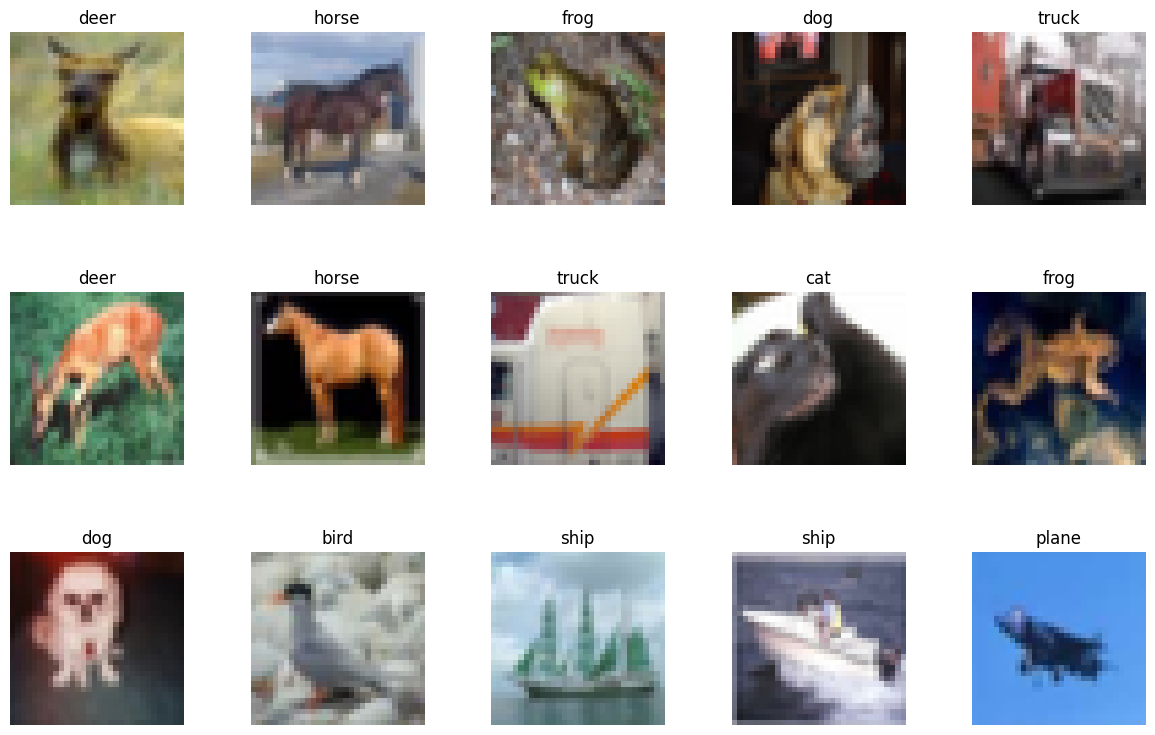

In [8]:
# visualizción imágenes

import random
import matplotlib.pyplot as plt

r, c = 3, 5
plt.figure(figsize=(c*3, r*3))
for row in range(r):
    for col in range(c):
        index = c*row + col
        plt.subplot(r, c, index + 1)
        ix = random.randint(0, len(trainset)-1)
        img, label = trainset[ix]
        plt.imshow(img)
        plt.axis('off')
        plt.title(classes[label])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [19]:
# convertimos imágenes a arrays de numpy

import numpy as np

train_images = np.array([np.array(img) for img, label in trainset])
test_images = np.array([np.array(img) for img, label in testset])

train_labels = np.array([label for img, label in trainset])
test_labels = np.array([label for img, label in testset])

In [20]:
# ver número de imágenes, resolución y número de canales

train_images.shape, test_images.shape, train_labels.shape, test_labels.shape

((50000, 32, 32, 3), (10000, 32, 32, 3), (50000,), (10000,))

In [21]:
# tipo de datos

train_images.dtype, train_labels.dtype

(dtype('uint8'), dtype('int64'))

In [22]:
# estadísiticos

max_value = train_images.max(axis=(0, 1, 2))
min_value = train_images.min(axis=(0, 1, 2))

max_value, min_value

(array([255, 255, 255], dtype=uint8), array([0, 0, 0], dtype=uint8))

In [23]:
mean = (train_images / 255).mean(axis=(0, 1, 2))
std = (train_images / 255).std(axis=(0, 1, 2))

mean, std

(array([0.49139968, 0.48215841, 0.44653091]),
 array([0.24703223, 0.24348513, 0.26158784]))

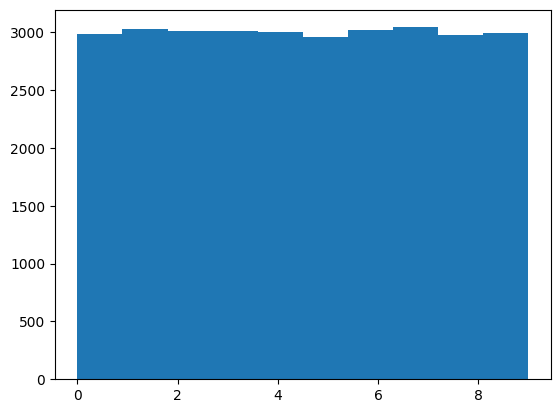

In [24]:
# distribución de clases

plt.hist(train_labels[:30000], bins=len(classes))
plt.show()

In [25]:
unique, counts = np.unique(train_labels, return_counts=True)
unique, counts

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000]))

En este caso nuestro dataset está balanceado (tenemos el mismo número de muestras por cada clase). En ocasiones, éste no será el caso. Entrenar un modelo con un dataset desbalanceado introducirá bias, haciendo que nuestro modelo sea más propenso a predecir las clases más presentes. Para solventar este problema existen varias opciones, la más común es sobre-muestrear las clases menos representadas (combinado con data augmentation puede ser especialmente positivo).

## Definiendo la red neuronal

A continuación se crear la arquitectura de la red neuronal.

In [26]:
def build_model(D_in=32*32*3, H=100, D_out=10):
    return torch.nn.Sequential(
        torch.nn.Linear(D_in, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, H),
        torch.nn.ReLU(),
        torch.nn.Linear(H, D_out)
    ).cuda()

Una muy buena manera de asegurarnos que nuestra red hace lo que debería es pasarle como entrada un tensor con las dimensiones esperadas durante el entrenamiento y asegurarnos que la salida que nos da coincide también con lo que esperamos. En nuestro caso, enviaremos tensores que contendrán un número determinado de imágenes (un batch, por ejemplo 64) y cada imagen estará representada por un vector de  32∗32∗3  valores. La salida debería ser un vector de 10 valores para cada imagen del batch representando la probabilidad de cada clase.

In [27]:
model = build_model()
test_input = torch.randn((64, 32*32*3)).cuda()
test_output = model(test_input)
test_output.shape

torch.Size([64, 10])

Si cometemos algún error definiendo nuestra red neuronal, en este paso lo podríamos detectar (en esta caso el MLP es una arquitectura muy sencilla, pero con redes neuronales grandes es muy fácil cometer errores a la hora de definir las dimensiones de cada capa).

### Fit de una muestra

Una vez nos hemos asegurado que las dimensiones de nuestra red están bien, el siguiente paso es asegurarnos de que es capaz de aprenderse de memoria una sola muestra del dataset. Si este no es el caso podemos estar seguros de que algo no anda bien.

In [28]:
import numpy as np

train_images = np.array([np.array(img) for img, label in trainset])
X_test = np.array([np.array(img) for img, label in testset])

train_labels = np.array([label for img, label in trainset])
y_test = np.array([label for img, label in testset])

X_train, X_val, X_subset = train_images[:40000], train_images[40000:], train_images[:5000]
y_train, y_val, y_subset = train_labels[:40000], train_labels[40000:], train_labels[:5000]

X_train.shape, X_val.shape, X_test.shape, X_subset.shape

((40000, 32, 32, 3), (10000, 32, 32, 3), (10000, 32, 32, 3), (5000, 32, 32, 3))

In [29]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X / 255.).float().cuda().view(-1, 32*32*3)
        self.Y = torch.from_numpy(Y).long().cuda()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]

In [32]:
# fit de la primera imagen del dataset

dataset = Dataset(X_subset[:1], y_subset[:1])
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1)

len(dataset)

1

### Entrenando el modelo

In [33]:
epochs = 5
criterion = torch.nn.CrossEntropyLoss()
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for e in range(1, epochs + 1):
    for x_b, y_b in dataloader:
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        print(f"Epoch {e}/{epochs} loss {loss.item():.5f} y {y_b.item()} y_pred {torch.argmax(y_pred, axis=1).item()}")

Epoch 1/5 loss 2.18248 y 6 y_pred 6
Epoch 2/5 loss 0.00004 y 6 y_pred 6
Epoch 3/5 loss 0.00000 y 6 y_pred 6
Epoch 4/5 loss 0.00000 y 6 y_pred 6
Epoch 5/5 loss 0.00000 y 6 y_pred 6


Podemos hacer el fit de una imagen sin problema. Errores como una función de pérdida incorrecta o diferentes dimensiones entre las predicciones y las etiquetas podrían ser detectados en este paso.

### Fit de un *batch*

Siguiendo la misma lógica, nuestro modelo debería ser capaz de aprenderse de memoria un solo *batch* de imágenes.

In [34]:
# fit de un batch

dataset = Dataset(X_subset[:64], y_subset[:64])
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

len(dataset)

64

In [36]:
epochs = 400
criterion = torch.nn.CrossEntropyLoss()
model = build_model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
for e in range(1, epochs+1):
    for x_b, y_b in dataloader:
        y_pred = model(x_b)
        loss = criterion(y_pred, y_b)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        acc = (y_b == torch.argmax(y_pred, axis=1)).sum().item()
        if not e % 10:
            print(f"Epoch {e}/{epochs} loss {loss.item():.5f} acc {acc}/{y_b.shape[0]}")

Epoch 10/400 loss 2.50472 acc 15/64
Epoch 20/400 loss 2.03323 acc 20/64
Epoch 30/400 loss 1.64344 acc 31/64
Epoch 40/400 loss 0.97772 acc 42/64
Epoch 50/400 loss 0.51328 acc 58/64
Epoch 60/400 loss 0.23147 acc 61/64
Epoch 70/400 loss 0.06227 acc 64/64
Epoch 80/400 loss 0.01648 acc 64/64
Epoch 90/400 loss 0.00635 acc 64/64
Epoch 100/400 loss 0.00357 acc 64/64
Epoch 110/400 loss 0.00248 acc 64/64
Epoch 120/400 loss 0.00197 acc 64/64
Epoch 130/400 loss 0.00165 acc 64/64
Epoch 140/400 loss 0.00143 acc 64/64
Epoch 150/400 loss 0.00126 acc 64/64
Epoch 160/400 loss 0.00113 acc 64/64
Epoch 170/400 loss 0.00102 acc 64/64
Epoch 180/400 loss 0.00092 acc 64/64
Epoch 190/400 loss 0.00084 acc 64/64
Epoch 200/400 loss 0.00077 acc 64/64
Epoch 210/400 loss 0.00071 acc 64/64
Epoch 220/400 loss 0.00066 acc 64/64
Epoch 230/400 loss 0.00061 acc 64/64
Epoch 240/400 loss 0.00057 acc 64/64
Epoch 250/400 loss 0.00053 acc 64/64
Epoch 260/400 loss 0.00050 acc 64/64
Epoch 270/400 loss 0.00047 acc 64/64
Epoch 280/

En este punto ya podemos estar bastante seguros de que nuestro modelo está bien definido, estamos usando la función de pérdida y optimizador adecuados, nuestro bucle de entrenamiento funciona bien, etc.

## Entrenando con un sub-conjunto de datos

Entrenar una `red neuronal` en un dataset completo puede ser computacionalmente costoso si el dataset es muy grande. Esto implica que si queremos hacer pruebas para probar diferentes combinaciones de hyperparámetros vamos a tener que esperar mucho tiempo, o alquilar grandes *clusters* de GPUs (lo cual es muy caro). Una solución es iterar utilizando un sub-conjunto representativo de nuestro dataset, confiando en que las conclusiones a las que lleguemos en este pequeño conjunto luego se transfieran a todo el dataset.

In [37]:
dataset = {
    'train': Dataset(X_subset, y_subset),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(5000, 10000)

In [39]:
from sklearn.metrics import accuracy_score

def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(axis=-1,keepdims=True)

def fit(model, dataloader, optimizer, scheduler=None, epochs=10, log_each=1, weight_decay=0, early_stopping=0, verbose=1):
    criterion = torch.nn.CrossEntropyLoss()
    l, acc, lr = [], [], []
    val_l, val_acc = [], []
    best_acc, step = 0, 0
    for e in range(1, epochs+1):
        _l, _acc = [], []
        for param_group in optimizer.param_groups:
            lr.append(param_group['lr'])
        model.train()
        for x_b, y_b in dataloader['train']:
            y_pred = model(x_b)
            loss = criterion(y_pred, y_b)
            _l.append(loss.item())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            y_probas = torch.argmax(softmax(y_pred), axis=1)
            _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().detach().numpy()))
        l.append(np.mean(_l))
        acc.append(np.mean(_acc))
        model.eval()
        _l, _acc = [], []
        with torch.no_grad():
            for x_b, y_b in dataloader['val']:
                y_pred = model(x_b)
                loss = criterion(y_pred, y_b)
                _l.append(loss.item())
                y_probas = torch.argmax(softmax(y_pred), axis=1)
                _acc.append(accuracy_score(y_b.cpu().numpy(), y_probas.cpu().numpy()))
        val_l.append(np.mean(_l))
        val_acc.append(np.mean(_acc))
        # guardar mejor modelo
        if val_acc[-1] > best_acc:
            best_acc = val_acc[-1]
            torch.save(model.state_dict(), 'ckpt.pt')
            step = 0
            if verbose == 2:
                print(f"Mejor modelo guardado con acc {best_acc:.5f} en epoch {e}")
        step += 1
        if scheduler:
            scheduler.step()
        # parar
        if early_stopping and step > early_stopping:
            print(f"Entrenamiento detenido en epoch {e} por no mejorar en {early_stopping} epochs seguidas")
            break
        if not e % log_each and verbose:
            print(f"Epoch {e}/{epochs} loss {l[-1]:.5f} acc {acc[-1]:.5f} val_loss {val_l[-1]:.5f} val_acc {val_acc[-1]:.5f} lr {lr[-1]:.5f}")
    # cargar mejor modelo
    model.load_state_dict(torch.load('ckpt.pt'))
    return {'epoch': list(range(1, len(l)+1)), 'loss': l, 'acc': acc, 'val_loss': val_l, 'val_acc': val_acc, 'lr': lr}

Por ejemplo, de la siguiente manera podríamos elegir un *learning rate* adecuado.

In [40]:
lrs = [0.0005, 0.0002, 0.0001]
hists = []
for lr in lrs:
    print(f"Probando lr {lr}")
    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = fit(model, dataloader, optimizer, epochs=10, verbose=0)
    hists.append(hist)

# tarda 12 segundos

Probando lr 0.0005
Probando lr 0.0002
Probando lr 0.0001


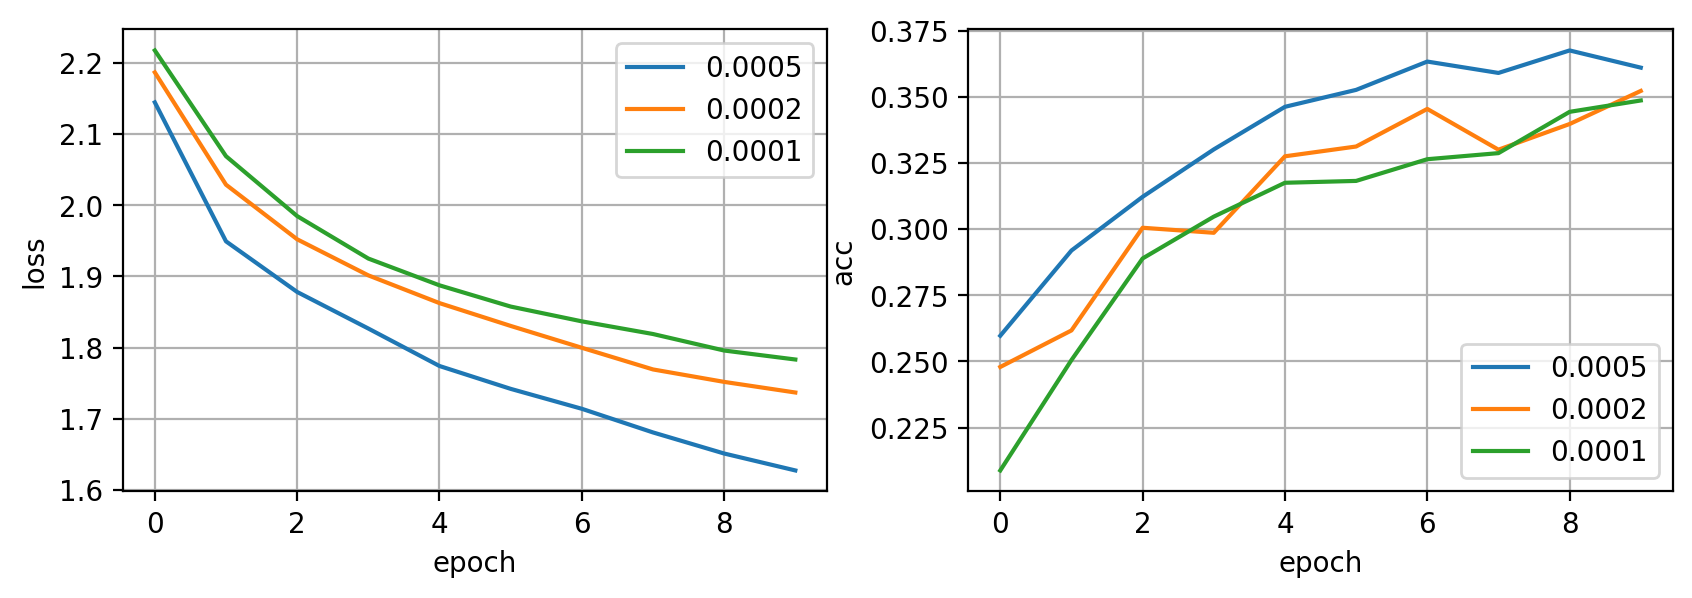

In [41]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
for i in range(len(lrs)):
    ax.plot(hists[i]['loss'], label=lrs[i])
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
for i in range(len(lrs)):
    ax.plot(hists[i]['val_acc'], label=lrs[i])
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Parece que el valor intermedio de 0.001 nos da los mejores resultados en este caso. Ahora repetimos el experimento con todos los datos.

In [43]:
dataset = {
    'train': Dataset(X_train, y_train),
    'val': Dataset(X_val, y_val),
}

dataloader = {
    'train': torch.utils.data.DataLoader(dataset['train'], batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
}

len(dataset['train']), len(dataset['val'])

(40000, 10000)

In [44]:
hists = []
for lr in lrs:
    print(f"Probando lr {lr}")
    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    hist = fit(model, dataloader, optimizer, epochs=10, verbose=0)
    hists.append(hist)

# tarda 1 minuto y 17 segundos

Probando lr 0.0005
Probando lr 0.0002
Probando lr 0.0001


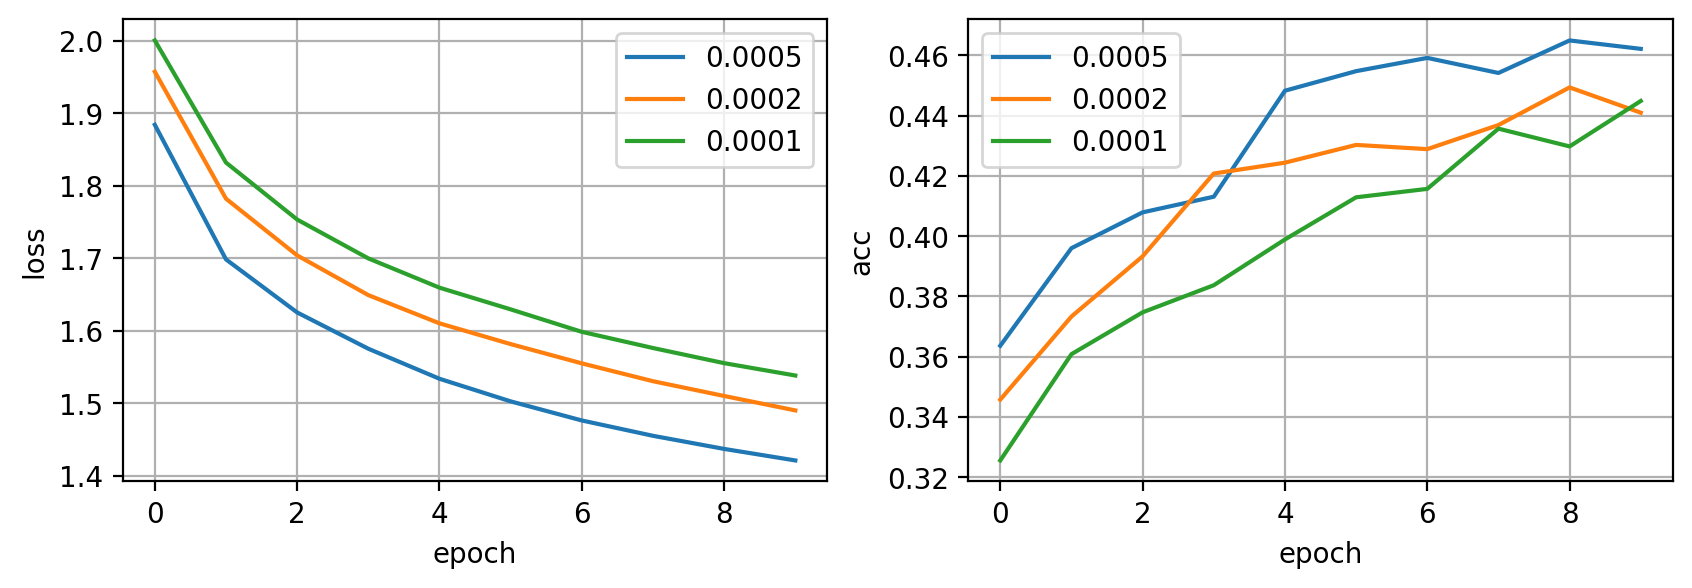

In [45]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
for i in range(len(lrs)):
    ax.plot(hists[i]['loss'], label=lrs[i])
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
for i in range(len(lrs)):
    ax.plot(hists[i]['val_acc'], label=lrs[i])
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

## Configuraciones recomendadas

Es fácil verse sobrepasado por el gran número de opciones que tenemos disponibles a la hora de entrenar nuestras redes, y obviamente no podemos probar todas las posibles combinaciones. Lo que podemos hacer es basarnos en el trabajo llevado a cabo por otros y utilizar sus resultados para empezar a trabajar. Estos son algunos buenos valores iniciales que puedes usar.

### Batch Size

Valores recomendados son: 16, 32, 64. Puedes empezar por estos valores y luego experimentar con otros. Aún así, la tendencia es intentar utilizar el *batch size* más grande posible que quepa en la memoria de la GPU (o GPUs) y adaptar el *learning rate* para obtener un buen entrenamiento.

In [46]:
bss = [16, 32, 64]
hists = []
for bs in bss:
    print(f"Probando bs {bs}")
    dataloader = {
        'train': torch.utils.data.DataLoader(dataset['train'], batch_size=bs, shuffle=True),
        'val': torch.utils.data.DataLoader(dataset['val'], batch_size=1000, shuffle=False)
    }
    model = build_model()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    hist = fit(model, dataloader, optimizer, epochs=10, verbose=0)
    hists.append(hist)

Probando bs 16
Probando bs 32
Probando bs 64


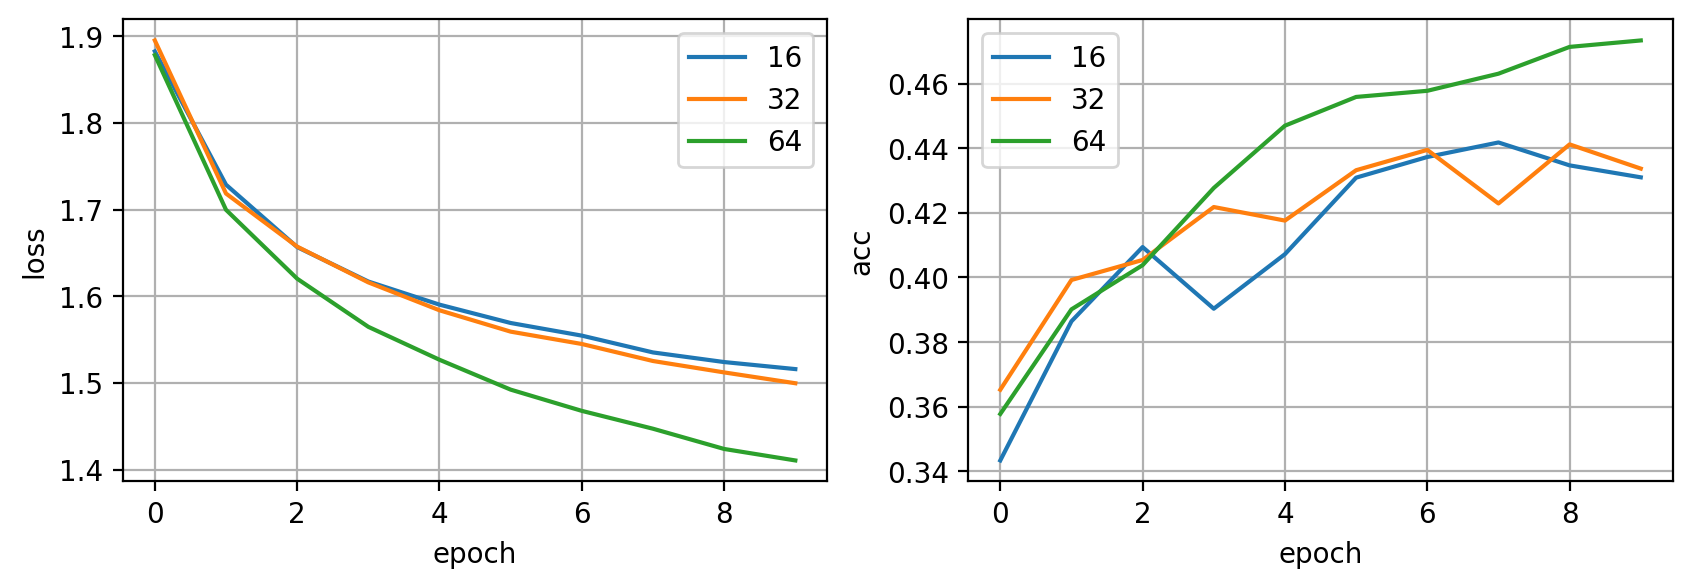

In [47]:
fig = plt.figure(dpi=200, figsize=(10,3))
ax = plt.subplot(121)
for i in range(len(bss)):
    ax.plot(hists[i]['loss'], label=bss[i])
ax.legend()
ax.grid(True)
ax.set_xlabel('epoch')
ax.set_ylabel('loss')
ax = plt.subplot(122)
for i in range(len(bss)):
    ax.plot(hists[i]['val_acc'], label=bss[i])
ax.legend()
ax.grid(True)
ax.set_ylabel('acc')
ax.set_xlabel('epoch')
plt.show()

Obtenemos el mismo resultado, pero necesitando mucho más tiempo y cálculo. Así pues, experimentar rápidamente en un subconjunto representativo nos puede dar una gran ventaja.

In [9]:
# print(f"Tamaño del dataset de entrenamiento: {len(train_dataset)} imágenes")
# print(f"Tamaño del dataset de prueba: {len(test_dataset)} imágenes")

# # Acceder al primer elemento del dataset
# first_image, first_label = train_dataset[0]  # Obtén la primera imagen y etiqueta
# print(f"Dimensiones de la primera imagen: {first_image.shape}")  # Mostrar las dimensiones


In [14]:
# Here we create our simple neural network. For more details here we are subclassing and
# inheriting from nn.Module, this is the most general way to create your networks and
# allows for more flexibility. I encourage you to also check out nn.Sequential which
# would be easier to use in this scenario but I wanted to show you something that
# "always" works.
class NNIMAGENET10(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NNIMAGENET10, self).__init__()
        # Our first linear layer take input_size, in this case 784 nodes to 50
        # and our second linear layer takes 50 to the num_classes we have, in
        # this case 10.
        self.fc1 = nn.Linear(input_size, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, num_classes)

        # self.fc1 = nn.Linear(input_size, 47)

    def forward(self, x):
        """
        x here is the mnist images and we run it through fc1, fc2 that we created above.
        we also add a ReLU activation function in between and for that (since it has no parameters)
        I recommend using nn.functional (F)
        """
        x = torch.flatten(x, start_dim=1)  # Aplanar la entrada desde (batch_size, channels, height, width) a (batch_size, input_size)

        x = self.fc1(x)
        x = torch.relu(x)
        # x = F.sigmoid(self.fc1(x))
        x = self.fc2(x)
        x = torch.sigmoid(x)
        x = self.fc3(x)
        return x

In [15]:
# Set device cuda for GPU if it's available otherwise run on the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Hyperparameters of our neural network which depends on the dataset, and
# also just experimenting to see what works well (learning rate for example).
input_size = 3072
num_classes = 10
learning_rate = 0.001
batch_size = 500
num_epochs = 50

cuda


In [16]:
# Initialize network
model = NNIMAGENET10(input_size=input_size, num_classes=num_classes).to(device)

In [17]:
# 3. Configuración de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [18]:
# 4. Entrenamiento del modelo
# Función corregida
def train_model(model, dataloader, criterion, optimizer, device, epochs=5):
    model.to(device)  # Mover el modelo al dispositivo especificado (CPU o GPU)
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in dataloader:
            # Mover los datos (inputs y labels) al mismo dispositivo que el modelo
            inputs, labels = inputs.to(device), labels.to(device)

            # Reiniciar los gradientes
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(dataloader)}')

# Uso del código corregido
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Seleccionar GPU si está disponible, de lo contrario CPU
train_model(model, train_loader, criterion, optimizer, device)

NameError: name 'train_loader' is not defined

In [ ]:
# 5. Evaluación del modelo
def evaluate_model(model, dataloader, device):
  model.to(device)
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for inputs, labels in dataloader:
      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)
      _, preds = torch.max(outputs, 1)
      correct += (preds == labels).sum().item()
      total += labels.size(0)
  print(f'Accuracy: {correct / total * 100:.2f}%')

evaluate_model(model, test_loader, device)

In [ ]:
# Load Training and Test data
train_dataset = datasets.EMNIST(root="dataset/", split="bymerge", train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.EMNIST(root="dataset/", split="bymerge", train=False, transform=transforms.ToTensor(), download=True)
print(len(train_dataset))
print(len(test_dataset))

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

In [ ]:
for c in train_dataset:
  print(c)

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# Train Network
for epoch in range(num_epochs):
    train_loss, train_acc = [], []

    # bar = tqdm(dataloader['train'])
    bar = tqdm(train_loader)
    for batch_idx, (data, targets) in enumerate(bar):
    # for batch_idx, (data, targets) in enumerate(tqdm(train_loader)):
    # for batch_idx, (data, targets) in enumerate(train_loader):

        # data, targets = batch.data, batch.targets
        # data, targets = data.to(device), targets.to(device)

        # Get data to cuda if possible
        data = data.to(device=device)
        targets = targets.to(device=device)

        # print(data.shape)
        # Get to correct shape
        data = data.reshape(data.shape[0], -1)
        # print(data.shape)
        # print("-"*30)
        # forward
        scores = model(data)
        print(scores.shape)
        print(targets.shape)
        loss = criterion(scores, targets)

        # backward
        optimizer.zero_grad()
        loss.backward()

        # gradient descent or adam step
        optimizer.step()
        train_loss.append(loss.item())
        acc = (targets == torch.argmax(scores, axis=1)).sum().item() / len(targets)
        train_acc.append(acc)
        bar.set_description(f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}")


In [ ]:
# Check accuracy on training & test to see how good our model
def check_accuracy(loader, model):
    num_correct = 0
    num_samples = 0
    model.eval()

    predicciones = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device=device)
            y = y.to(device=device)
            x = x.reshape(x.shape[0], -1)

            scores = model(x)
            _, predictions = scores.max(1)
            predicciones.append(predictions)

            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

    model.train()
    return num_correct/num_samples, predicciones

p_train, pred_train  = check_accuracy(train_loader, model)
p_test, pred_test  = check_accuracy(test_loader, model)

print(f"Accuracy on training set: {p_train*100:.2f}")
print(f"Accuracy on test set: {p_test*100:.2f}")